## 第6章: 针对分类任务的微调

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "tiktoken",    # Tokenizer
        "torch",       # Deep learning library
        "tensorflow",  # For OpenAI's pretrained weights
        "pandas"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.4.0
tiktoken version: 0.12.0
torch version: 2.9.1
tensorflow version: 2.20.0
pandas version: 2.3.3


在此之前，我们已经基本搭建并实现了 GPT 模型的整体框架。接下来我们会通过一个非常直观的微调示例来继续学习，用现成的预训练模型做电子邮件的垃圾邮件分类。

所谓微调，可以理解为“在预训练模型的基础上做二次训练”。预训练模型已经学到了大量通用语言能力，但它未必能直接满足你的具体目标，比如做分类、做问答，或者做一个更贴合你需求的个人助手。微调的作用就是把模型的能力进一步对齐到某个明确任务或使用场景上，让它在该任务上表现更稳定、更符合预期。

### 6.1 不同类型的微调

语言模型最常见的两种微调方式是指令微调和分类微调。指令微调的形式如下图所示，也是下一章将要重点讲解的内容。

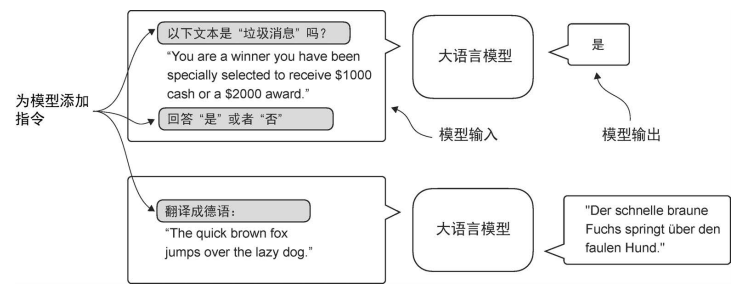

本章要讲的是分类微调，它很像训练一个卷积神经网络去识别手写数字那样，给定输入，让模型输出一个固定的类别结果。

在分类微调中，模型的输出类别是预先定义好的，数量也是固定的，例如只能输出“垃圾邮件（spam）”或“非垃圾邮件（not spam）”。因此，分类微调后的模型只能预测它在训练阶段见过的那些类别，无法凭空输出新的类别。相比之下，指令微调的模型通常更“通用”，往往可以在一个模型里完成多种不同任务。

可以把分类微调的模型理解为一种高度专用的模型，它专注解决某一个明确问题。在实际项目里，做出一个在单一任务上表现稳定的“专用模型”，通常比训练一个能同时在很多任务上都表现优秀的“通用模型”更容易。

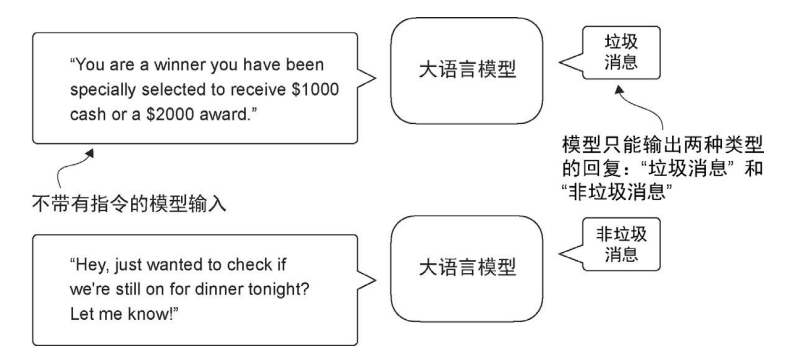

### 6.2 准备数据集

本节将完成用于分类微调的数据集准备工作。我们会使用一个由“垃圾消息”和“非垃圾消息”组成的文本数据集，对大模型进行微调，使其学会对输入消息进行垃圾分类。首先，我们需要下载并解压该数据集。

In [3]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip" # 数据集压缩包地址（UCI 官方镜像）
zip_path = "sms_spam_collection.zip" # 本地保存的 zip 文件名
extracted_path = "sms_spam_collection" # 解压到的目录
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv" # 我们希望最终得到的 TSV 文件路径（便于后续按表格数据读取）


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
     # 幂等性检查：如果目标文件已经存在，就跳过下载/解压，避免重复工作
    
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
     # 发起下载请求：stream=True 表示使用“流式下载”，不会一次性把文件全部读进内存
     # timeout=60 防止网络卡住一直等待
        return

    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
     # 将下载内容写入本地 zip 文件：iter_content 按块读取，节省内存
        
        for chunk in response.iter_content(chunk_size=8192):
            if chunk: # 过滤 keep-alive 空块，避免写入无效内容
                out_file.write(chunk)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:  # 解压 zip 到指定目录
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
     # 数据集原始文件名没有后缀（SMSSpamCollection），这里重命名为 .tsv
     # 方便后续明确按“制表符分隔”的格式读取 
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
     # 先尝试从主 URL下载
    
except (requests.exceptions.RequestException, TimeoutError) as e:
     # 如果网络/超时等异常导致主 URL 失败，就切换到备用镜像地址重试
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


该数据集以制表符分隔（TSV）的文本文件形式保存，因此我们可以直接将其读取并加载到 pandas 的 DataFrame 中，便于后续清洗、分析和建模。

我们拿到的数据集其实就是一个普通的文本文件，只不过它的每一行都按“制表符”分成了几列，这种格式通常叫 TSV。

为了后续处理更方便，我们会用一个叫 pandas 的工具把它读进来。pandas 可以把它理解成 Python 里专门用来处理表格数据的“数据处理助手”，它能很轻松地完成读取文件、查看数据、筛选行列、统计数量、处理缺失值等操作。

读进来之后，数据会被放进一个叫 DataFrame 的结构里，DataFrame 类似一张“电子表格”或“数据库里的表”，有行有列，每一列代表一种信息（比如标签是 spam 还是 not spam，文本内容是什么），每一行代表一条样本记录。有了 DataFrame，我们就能像操作表格一样直观地处理数据，为后面的训练和微调打好基础。

In [5]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
"""
读取 TSV 文件（sep="\t" 表示用“制表符”分隔每一列）
header=None 表示文件第一行不是表头，而是数据本身
当我们查看类别分布时，会发现数据集中“ham”（也就是“非垃圾邮件”）的数量远多于“spam”（垃圾邮件）。names=["Label", "Text"] 手动指定两列的列名：Label（标签）和 Text（短信内容）
"""
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


当我们查看类别分布时，会发现数据集中“ham”（非垃圾邮件）的数量远多于“spam”（垃圾邮件）。

In [6]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


为了让数据集规模小一些，这样微调大模型会更快、更容易跑通流程，我们对原始数据做**下采样（也叫欠采样）**，让“spam”和“ham”两类的数据数量变得一样多，最终每一类各保留 747 条样本。

In [8]:
def create_balanced_dataset(df):
    
    num_spam = df[df["Label"] == "spam"].shape[0]
    # 统计 spam（垃圾短信）的样本数量：后面用它作为“目标数量”
    
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    # 从 ham（非垃圾短信）里随机抽取与 spam 数量相同的样本，实现“欠采样”

    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    # 将抽取出来的 ham 子集与所有 spam 样本合并，得到类别均衡的数据集

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


接下来，我们会把原本用字符串表示的类别标签“ham”和“spam”转换成整数标签 0 和 1，便于模型训练与计算处理。


In [9]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    

In [10]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


然后我们将定义一个函数，用随机的方式把数据集划分为训练集、验证集和测试集三个子集。

In [13]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    # 先把整个数据集随机打乱，避免原始数据的排列顺序影响划分结果
    # frac=1 表示“抽取 100% 的行”，相当于全量洗牌

    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)
    # 计算切分位置：训练集结束下标、验证集结束下标

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    # 按下标范围切分成三份：训练集 / 验证集 / 测试集
    # 测试集不需要显式传比例，直接用“剩余部分”即可

    return train_df, validation_df, test_df
    # 按 70% 训练、10% 验证切分；剩下的 20% 自动作为测试集

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
    # 将三份数据分别保存为 CSV 文件，方便后续训练/评估时直接加载使用
    # index=None 表示不把 pandas 的行索引写入文件，避免多出一列无用信息

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

我们把已经处理好的数据集随机切成三份，分别用于训练、调参和最终评估。做法是先把整个 DataFrame “洗牌”，也就是随机打乱行顺序，避免数据原本的排列方式影响划分结果。接着根据设定的比例计算切分位置：前 70% 作为训练集，用来让模型学习；中间 10% 作为验证集，用来在训练过程中观察效果、调整超参数或做早停；剩下的 20% 作为测试集，用来在所有开发工作完成后做一次相对客观的最终评估。

分完成后，我们把三份数据分别保存成 train.csv、validation.csv 和 test.csv。这样做的好处是流程更清晰，也更方便复现：后续无论是在不同的脚本里训练模型，还是在不同机器上跑实验，都可以直接加载这三个文件，不需要每次都重新切分数据。

### 6.3 创建数据加载器

**数据加载器**可以理解为训练时的数据“供给系统”。它把我们已经切分好的训练集、验证集和测试集逐条读取出来，完成必要的预处理（例如把文本转换成 token 序列），并把样本按 batch 组织好送进模型。这样在模型训练时通常不会一条一条样本地跑，而是用 batch 并行计算来提升效率，同时也便于我们控制训练过程中的随机打乱、采样和评估节奏。

当我们把多条文本样本合并成一个 batch 一起送入模型时，会遇到一个最常见的问题：每条消息的长度不同，而模型在同一个 batch 里需要形状一致的张量。为了解决这个矛盾，我们必须把样本处理成统一长度。常见做法是截断或补齐，本课程采用补齐策略，把较短的消息在末尾补到固定长度，并使用 `<|endoftext|>` 作为补齐用的 padding token（占位符token）。

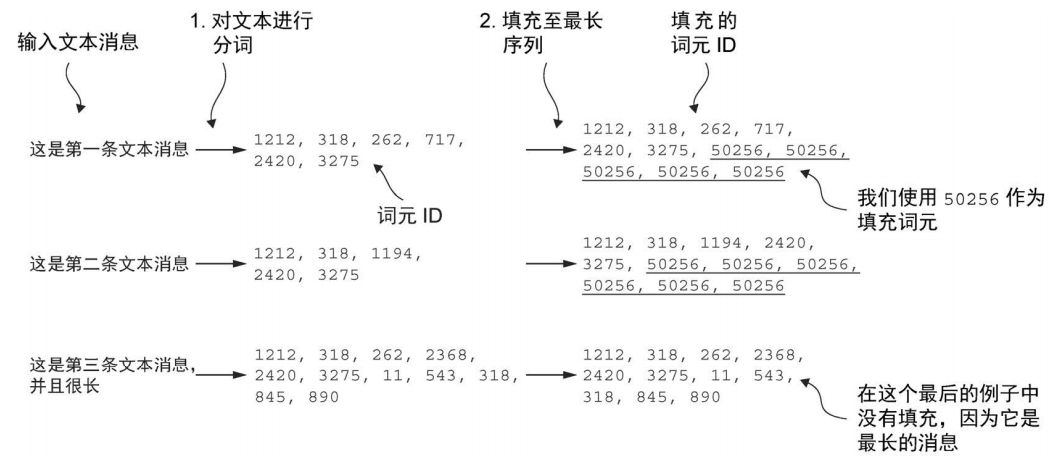

In [14]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


下面的`SpamDataset`类会先找出训练数据集中最长的序列长度，然后对其他较短的序列在末尾补上 padding token，使它们的长度都与最长序列一致。

In [17]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        # 读取 CSV，期望至少包含两列：Text（文本）和 Label（标签）
        self.data = pd.read_csv(csv_file)

        self.encoded_texts = [
        # 预先把所有文本分词并编码成 token id 序列，避免每次取样本时重复编码
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
        # 决定序列的统一长度（max_length）
        # 如果用户没指定，就用训练集中“最长序列”的长度作为统一长度
            self.max_length = self._longest_encoded_length()

        else:
         # 如果指定了 max_length，则把超过这个长度的序列截断
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        self.encoded_texts = [
          # 补齐（padding）：把所有序列补到同样长度 self.max_length
          # pad_token_id 是补齐用的 token（这里默认 50256，对应 GPT2 的 <|endoftext|>）
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
          # DataLoader 会通过 __getitem__ 逐条取数据
          # 返回 (输入序列, 标签)，并转成 torch.Tensor，便于送进模型训练
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self): # 告诉 DataLoader 数据集一共有多少条样本
        return len(self.data)

    def _longest_encoded_length(self):
          # 扫描所有编码后的序列，找到最长的长度
          # 用这个长度作为 padding 的目标长度
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

这段代码定义了一个 `SpamDataset`，它的作用是把我们在 CSV 里保存的短信数据变成 PyTorch 能直接用于训练的“数据集对象”。在训练时，我们希望模型拿到的是数字而不是原始字符串，因此 `SpamDataset` 在初始化阶段就会读取文件，然后用 `tokenizer` 把每条短信编码成一串 token id。这里选择 **“预先编码”（pre-tokenize）** 很关键，因为训练过程中会反复取样本，如果每次取样本才编码，会明显拖慢速度。

编码完成后，代码解决了 `batch` 训练必须面对的长度对齐问题。它先确定一个统一长度 `max_length`,如果你没有手动指定，就以当前数据集中最长序列的长度为准；如果指定了 `max_length`，就会把超长的序列截断，避免出现极端长文本把整体长度拉得太大。确定统一长度之后，再把每条较短的序列在末尾补上 `pad_token_id`，让所有序列都变成同样长度，便于后续用 `DataLoader` 组成 `batch`。

最后，`__getitem__` 和 `__len__` 是 PyTorch 数据集的标准接口。`__getitem__ `定义“给我第 index 条样本时返回什么”，这里返回的是一条已经补齐过的 token 序列，以及对应的类别标签，并且都转换成 `torch.tensor` 以便直接送入模型。

`__len__` 则告诉 `DataLoade`r 数据集中一共有多少条样本。有了这个 `SpamDataset`，后面创建 `DataLoader` 时就能稳定地批量读取数据、随机打乱、并行加载，从而进入真正的微调训练流程。

In [18]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


验证集和测试集也会按照训练集中最长序列的长度进行补齐。需要注意的是，如果验证集或测试集中某些样本比训练集中最长样本还要长，那么在 `SpamDataset` 里会通过 `encoded_text[:self.max_length] `将它们截断到同样的最大长度。这样做并不是必须的，只是一种可选的处理方式；即使在验证集和测试集里同样把 `max_length=None` 交给代码自行决定最大长度，整体流程也一样可以正常运行。

In [19]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

下面我们就可以基于这个数据集类来创建 DataLoader，整体过程与前面章节中创建 DataLoader 的方式类似。

In [22]:
from torch.utils.data import DataLoader

num_workers = 0 # 数据加载使用的子进程数量；0 表示在主进程中加载（更稳定）
batch_size = 8  # 每个 batch 包含的样本数

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
# 训练集 DataLoader：训练时通常需要打乱数据顺序（shuffle=True），提升训练稳定性
# drop_last=True：如果最后剩下不足一个 batch 的样本，就丢弃它，保证每个 batch 形状一致

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
# 验证集 DataLoader：验证时不需要打乱（默认 shuffle=False），便于稳定对比评估结果
# drop_last=False：保留最后不满一个 batch 的数据，避免浪费验证样本

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
# 测试集 DataLoader：同验证集，通常不打乱，并保留所有样本用于最终评估

作为验证步骤，我们会遍历这些 DataLoader，检查每个 batch 是否包含 8 条训练样本，并确认每条样本都被处理成长度为 120 个 token 的序列。

In [23]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


最后，我们打印训练集、验证集和测试集中各自包含的 batch 总数。

In [24]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### 6.4 初始化带有预训练权重的模型

在本节中，我们将初始化上一章中使用过的预训练模型。

In [25]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # 词表大小：模型能识别的 token 总数
    "context_length": 1024,  # 最大上下文长度：一次最多处理多少个 token
    "drop_rate": 0.0,        # dropout 比例：这里设为 0 表示不启用 dropout
    "qkv_bias": True         # 注意力层 Q/K/V 线性映射是否使用 bias
}

model_configs = {  # 不同 GPT-2 规模的“差异配置”（层数、隐藏维度、注意力头数等）
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
# 将所选模型的差异配置合并到 BASE_CONFIG，得到完整的模型初始化参数

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)
# 关键检查：数据序列长度不能超过模型的最大上下文长度，否则训练/前向会报错
# 如果超过，就提示你重新构造数据集，并把 max_length 设为 context_length

在开始初始化预训练模型之前，我们先把模型需要的配置参数整理好，并确保数据的长度不会超出模型的处理上限。

代码里通过 `CHOOSE_MODEL` 选择要使用的 GPT-2 规格，例如 `gpt2-small (124M)`。接着用 `BASE_CONFIG` 提供所有 GPT-2 版本通用的基础设置，包括词表大小 `vocab_size`、最大上下文长度 `context_length`，以及一些实现层面的开关参数。

不同模型规模之间最主要的差别在于网络结构本身，比如隐藏维度 `emb_dim`、Transformer 层数 `n_layers`、注意力头数 `n_heads`，这些差异被集中写在 `model_configs` 里。通过 `BASE_CONFIG.update(model_configs[CHOOSE_MODEL])`，所选模型的结构参数会合并进基础配置，形成一份完整的模型初始化配置，后面就可以用它来构建模型并加载对应的预训练权重。

在训练之前还需要做一个关键的长度校验。前面为了能按 `batch` 训练，我们把每条短信补齐或截断到统一长度 `train_dataset.max_length`，但 GPT-2 能接收的输入长度有硬性上限，也就是 `context_length`（这里是 1024）。

如果数据序列长度超过这个上限，模型在前向计算时会出现维度不匹配或越界错误。代码中的 `assert` 就是在训练开始前把这个问题拦下来：一旦发现数据长度超过模型允许的最大长度，就直接报错并给出明确提示，要求你重新构造数据集，把 `max_length` 调整到不超过 `context_length`，从而避免把错误带到更后面的训练流程里。

In [27]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
# 从 CHOOSE_MODEL 里解析出模型规模标识（例如 "gpt2-small (124M)" -> "124M"）
# 这个标识用于告诉下载函数应该下载哪一档 GPT-2 权重

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
# 下载并加载对应规模的 GPT-2 预训练权重
# settings 通常包含模型的相关元信息；params 是实际的权重参数（用于灌入到模型里）

model = GPTModel(BASE_CONFIG)
# 用 BASE_CONFIG 初始化我们自己实现的 GPTModel（结构要与对应的 GPT-2 规格一致）

load_weights_into_gpt(model, params)
# 将下载到的预训练权重 params 加载到我们创建的 model 中

model.eval();
# 切换到评估模式：关闭 dropout 等训练时才启用的随机行为，便于稳定推理/验证

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


为了确认模型是否被正确加载，我们可以做一次简单的验证：让它生成一段文本，检查输出是否连贯、符合语言逻辑。

In [29]:
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

text_1 = "Every effort moves you"  # 作为提示词（prompt），用于测试模型是否能正常生成

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


在把模型正式微调成分类器之前，我们先做一个简单测试：不训练模型，只通过提示词（prompting）的方式看看它是否已经具备一定的垃圾短信识别能力，能不能直接把短信判断为 spam 或 not spam。

In [30]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


从结果可以看出，这个模型并不擅长按照指令去完成任务。这个现象是正常的，因为它目前只是做过预训练，还没有经过指令微调。

### 6.5 添加分类头

在本节中，我们会对预训练大模型做一些结构上的调整，使它能够用于分类微调。在动手之前，我们先回顾一下模型的整体架构。

In [32]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

从上面的结构图可以看到，我们在第 4 章实现的模型架构已经完整呈现出来。我们不打算把整个模型从头训练一遍，而是把输出层替换成适用于分类任务的形式，并对这部分进行微调。

为此，第一步通常是“冻结”模型，也就是把除目标层以外的参数都设为不可训练，让大部分网络权重保持不变，只在需要的部分进行更新。

In [33]:
for param in model.parameters():
    param.requires_grad = False

在 PyTorch 里，模型的每一个参数（权重、偏置）都有一个 `requires_grad` 开关，用来决定训练时是否需要为它计算梯度并更新它。这里用一个循环遍历 `model.parameters()`，把所有参数的 `requires_grad` 统一设为 `False`，等价于“冻结整个模型”。

冻结之后，这些层在反向传播时不会计算梯度，优化器也不会更新它们的值，从而把训练的重点限制在我们后面新加或解冻的分类相关层上。这样做的好处是训练更快、需要的数据更少。

接下来，我们会替换模型的输出层`model.out_head`。在原始的语言模型里，这一层的作用是把最后一层的隐藏表示映射到 50,257 维，也就是词表大小，用于预测“下一个 token 是什么”。但现在我们的目标变成了二分类任务，只需要输出两个类别（“spam”和“not spam”），因此可以把输出层替换成一个输出维度为 2 的线性层。新建的输出层参数默认是可训练的，因此后续微调时它会被更新。

另外，为了让代码不绑定某个固定模型规模，我们会使用 `BASE_CONFIG["emb_dim"]`作为输入维度。对于 gpt2-small (124M) 来说它等于 768，但如果你切换到 medium/large/xl，emb_dim 会随之变化，代码依然可以直接复用。

In [34]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

从技术上说，只训练新的输出层就已经可以完成分类微调了。不过一些实验结果显示，在输出层之外再额外微调少量模型层，往往能带来更明显的性能提升。因此这里不仅训练输出层，还会把最后一个 Transformer 模块以及连接最后一个 Transformer 模块与输出层之间的最终 LayerNorm 一并设为可训练，让模型在保持大部分参数稳定的同时，获得更强的任务适配能力。

In [35]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

我们仍然可以像前面章节那样使用这个模型进行前向计算。比如，我们可以先给它输入一段文本，看看它的输出情况。

In [39]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) 

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


与前面章节相比，最大的不同在于模型的输出维度从原来的 50,257（词表大小）变成了 2，也就是对应二分类任务的两个类别输出。

In [40]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) 

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


模型会为每一个输入 token 生成一个对应的输出向量。因为我们这里输入的文本一共包含 4 个 token，所以模型输出也会包含 4 个二维向量，也就是 4 个形状为 2 的输出结果。

在因果注意力机制下，序列里越靠后的 token，能汇聚到的上下文信息通常越多。以长度为 4 的输入为例，第 4 个（也就是最后一个）token 是唯一一个能够访问到前面所有 token 信息的位置，因此它包含的整体信息最充分。

也正因为如此，在做垃圾短信二分类时，我们会重点使用最后一个 token 对应的输出表示，并围绕它来进行微调，让模型学会根据整段文本的综合信息判断是 spam 还是 not spam。

In [41]:
 print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


### 6.6 计算分类损失和准确率

在讲解损失函数如何计算之前，我们先简单看一下，模型输出的结果是如何被转换成最终的类别标签的。

In [43]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


和第 5 章的做法类似，我们会先对模型输出的 `logits` 使用 `softmax` 转换成概率分布，然后用 `argmax` 取概率最大的那个位置索引，把它作为模型预测的类别标签。

In [44]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


这里并不一定要显式计算 `softmax`，`softmax` 不会改变各个输出值的大小规律，因此输出最大的那个 `logit` 对应的也会是概率最大的类别，用 `argmax` 直接在 `logits` 上取最大值同样能得到相同的预测结果。

In [45]:
logits = outputs[:, -1, :] # 取出“最后一个 token”的输出，并保留所有类别维度，因此得到的就是用于分类的 logits
label = torch.argmax(logits) # 找到数值最大的那个位置，把它当作模型预测的类别编号
print("Class label:", label.item())

Class label: 1


我们可以用同样的思路计算分类准确率，也就是模型在某个数据集上预测正确的样本占比。做法是对数据集里的每个样本都运行前面基于 `argmax` 的预测步骤，然后统计预测正确的数量，并用正确数量除以总样本数，得到最终的准确率。

In [47]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval() 
    correct_predictions, num_examples = 0, 0  # 统计：预测正确的数量、样本总数

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    # num_batches=None 表示遍历整个 data_loader
    # 否则只评估前 num_batches 个 batch（用于快速验证/调试）

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

        
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]
                # 模型输出形状通常是 [batch_size, seq_len, num_classes]
                # 这里取最后一个 token 的输出作为分类 logits：[:, -1, :]

            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
            # 累计样本数与预测正确数
        else:
            break
            
    return correct_predictions / num_examples

分类任务里最常用的评估指标之一是准确率，也就是“预测正确的样本占总样本的比例”。实现时通常会把模型切到评估模式`model.eval()`，然后遍历 DataLoader 逐个 batch 取数据，把输入和标签移动到指定设备上。评估阶段不需要计算梯度，所以会放在 `torch.no_grad()` 环境里做前向计算，这样更省显存也更快。

对于我们这个二分类模型，前向输出对每个token都给出一个logits向量，但真正用于整段文本分类的是最后一个token的输出，因此使用 `model(input_batch)[:, -1, :]` 取出每条样本的分类logits。随后在类别维度上做`argmax`得到预测标签，与真实标签逐个比较并累加正确数量与样本总数，最后用正确数除以总数得到准确率。参数`num_batches`允许只评估前几个batch，用来快速检查流程是否正常，确认无误后再跑完整数据集。

接下来，我们用这个函数分别计算训练集、验证集和测试集上的分类准确率。

In [49]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

model.to(device) 

torch.manual_seed(123) 

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)
#计算准确率：这里 num_batches=10 表示只用前 10 个 batch 做快速评估（调试/验证用）

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Device: mps
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


从结果可以看出，目前的预测准确率并不理想，因为我们还没有对模型进行微调。

在开始微调之前，我们需要先明确训练过程中要优化的损失函数。我们的目标是让模型的垃圾短信分类准确率尽可能高，但准确率本身不是可微分的函数，没法直接用梯度下降去优化。因此实际训练时通常会选择一个可微分、并且和准确率提升方向一致的替代目标，这里使用**交叉熵损失**来作为“代理目标”，通过最小化交叉熵来间接推动准确率上升。

In [50]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)

    logits = model(input_batch)[:, -1, :]  
    # 前向计算得到输出后，只取最后一个 token 的 logits 作为整段文本的分类依据

    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    # 用交叉熵计算分类损失：logits 是未归一化分数，target_batch 是真实类别索引

    return loss

`cross_entropy(logits, target_batch)` 会把logits和真实类别索引对齐，输出一个标量损失值；损失越小，说明模型把正确类别的分数推得越高。这个损失值就是后续反向传播要优化的目标。

In [51]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    # 用来累计多个 batch 的损失（会把每个 batch 的 loss 加起来）

    if len(data_loader) == 0:
        return float("nan")
        # 如果数据加载器为空，直接返回 NaN，避免后面除以 0

    elif num_batches is None:
        num_batches = len(data_loader)
        # num_batches 不指定时，默认遍历整个 data_loader 的所有 batch

    else:
        num_batches = min(num_batches, len(data_loader))
        # 如果指定的 num_batches 超过实际 batch 数，就取较小值，防止越界

    for i, (input_batch, target_batch) in enumerate(data_loader):
        # 遍历 data_loader，每次拿到一个 batch 的输入和标签

        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            # 计算当前 batch 的损失（内部会取最后一个 token 的 logits 并算交叉熵）

            total_loss += loss.item()
            # loss 是张量，这里用 .item() 取出 Python 浮点数便于累加

        else:
            break
            # 达到指定 batch 数后提前结束（用于快速评估）

    return total_loss / num_batches

训练时需要一个稳定的指标来判断模型是否真的在进步，而单个 batch 的 loss 波动很大，容易被“这批数据刚好更难/更简单”误导。把多个 batch 的 loss 汇总并求平均，相当于用更多样本对当前模型做一次更可靠的抽样评估，让这个数更能代表模型在数据分布上的整体拟合程度。这样你才能用它来比较不同训练轮次、不同数据集（训练/验证/测试）之间的差异，并据此判断收敛、过拟合等现象。

同时，训练过程需要在“评估可靠性”和“计算开销”之间做权衡。频繁跑完整个数据集会很慢，所以提供`num_batches`让你在调试或训练中期用少量batch快速估计趋势；等到关键节点再做全量评估。空的DataLoader返回 NaN 是为了让数据管道问题尽早暴露出来，而不是给出一个看似正常但其实误导的数值。最后返回平均loss而不是累积loss，是为了消除数据规模和 batch 数量的影响，保证不同场景下的结果具有可比性。

在正式开始训练之前，我们会先用`calc_loss_loader`分别计算训练集、验证集和测试集的初始损失值，作为训练前的基线对照。

In [53]:
with torch.no_grad(): 
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 1.937
Validation loss: 2.583
Test loss: 2.322


### 6.7 在有监督数据上微调模型

在本节中，我们将定义并使用训练函数，通过微调来提升模型的分类准确率。下面的 `train_classifier_simple` 与第 5 章用于预训练的 `train_model_simple` 基本一致，整体训练流程没有变化。主要只有两点不同：第一，我们现在统计的是已经见过的训练样本数（`examples_seen`），而不是见过的 token 数；第二，我们在每个 epoch 结束后计算并记录分类准确率，而不再像预训练那样在每个 epoch 后输出一段示例生成文本。

In [54]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    # 用列表记录训练/验证损失与训练/验证准确率，便于后续画曲线或做对比分析

    examples_seen, global_step = 0, -1
    # examples_seen 统计已见过的训练样本数；global_step 统计走过的 batch 步数（用于按频率评估）

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            # 清空上一轮反向传播残留的梯度，避免梯度累加干扰当前更新

            loss = calc_loss_batch(input_batch, target_batch, model, device)
            # 计算当前 batch 的分类损失（基于最后一个 token 的 logits 和交叉熵）

            loss.backward()
            optimizer.step()
            # 参数更新：根据梯度对可训练参数做一次优化步

            examples_seen += input_batch.shape[0]
            # 累计本轮看到的样本数（一个 batch 里有多少条样本就加多少）

            global_step += 1
            # 训练步数加 1，用于控制评估频率

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                # 按指定频率做一次阶段性评估，得到训练集/验证集的平均损失（通常只取 eval_iter 个 batch）

                train_losses.append(train_loss)
                # 记录训练集损失，便于后续观察训练过程的变化趋势

                val_losses.append(val_loss)
                # 记录验证集损失，用于监控泛化表现与过拟合迹象

                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                # 打印阶段性损失，快速查看训练是否在收敛

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        # 每个 epoch 结束后计算训练集准确率（通常只用 eval_iter 个 batch 做近似估计）

        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        # 同样计算验证集准确率，用来观察模型是否真正学会分类且能泛化

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")

        train_accs.append(train_accuracy)
        # 记录训练集准确率，便于后续画曲线

        val_accs.append(val_accuracy)
        # 记录验证集准确率，便于后续画曲线

    return train_losses, val_losses, train_accs, val_accs, examples_seen

训练流程仍然是标准的“前向计算损失 → 反向传播 → 优化器更新参数”，按 epoch 反复遍历训练集，让模型逐步学会把文本分到正确类别。由于前面冻结了大部分参数，这里主要更新分类头和少量解冻层，相当于在保留预训练能力的基础上做任务适配。

训练过程中会定期评估并记录训练/验证 loss，用来观察是否在收敛；每个 epoch 结束再计算一次训练/验证准确率，直接衡量分类效果。`eval_iter` 只取部分 batch 做快速评估，目的是在不显著拖慢训练的情况下获取稳定的趋势信号，关键节点再做全量评估即可。

`train_classifier_simple`中使用的`evaluate_model`与第5章中的实现是相同的。

In [56]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [57]:
import time
start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
# 定义优化器：AdamW 常用于微调
# lr=5e-5 是较常见的微调学习率量级；weight_decay 用于权重衰减，帮助正则化、减少过拟合

num_epochs = 5
# 训练轮数：训练集会被完整遍历 5 次

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)
# 开始训练分类器
# eval_freq=50 表示每训练 50 个 step 评估一次 loss
# eval_iter=5 表示评估时只用前 5 个 batch 做快速估计（更省时间）

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 1.84 mi

我们也可以使用 matplotlib 将训练集和验证集的损失曲线画出来，以便直观看到训练过程中损失是否下降，以及验证集表现是否同步改善。

In [58]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny() 
    ax2.plot(examples_seen, train_values, alpha=0)  
    ax2.set_xlabel("Examples seen")

    fig.tight_layout() 
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

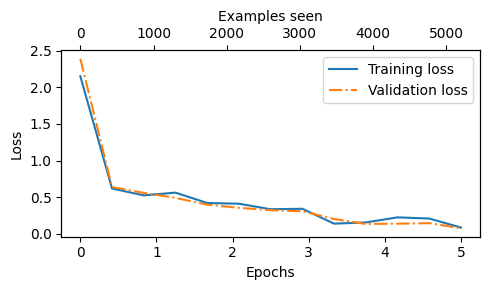

In [59]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

从上面的曲线可以看出，损失整体呈下降趋势，说明模型在训练过程中确实学到了有用的分类能力。与此同时，训练集损失和验证集损失非常接近，这通常意味着模型没有明显过拟合：它不仅在训练数据上变好，在未见过的验证数据上也保持了相似的表现。用同样的方式，我们也可以把准确率曲线画出来，进一步直观看到分类效果随训练轮次的提升情况。

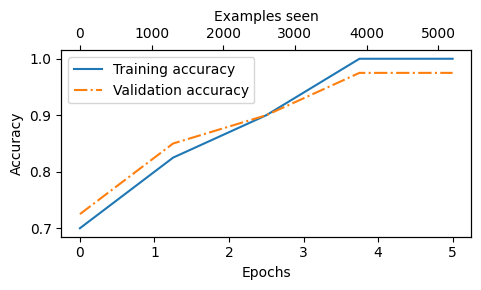

In [60]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

从上面的准确率曲线可以看出，训练到第 4、5 个 epoch 时，模型在训练集和验证集上都达到了相对较高的准确率。不过需要注意的是，我们之前在训练函数里设置了 `eval_iter=5`，这表示每次评估时只用前 5 个 batch 来做快速估计，因此这些准确率并不是全量数据集上的精确结果。

如果想得到更可靠的指标，我们可以在训练结束后对训练集、验证集和测试集进行一次全量评估，也就是遍历各自 DataLoader 的所有 batch，计算完整数据集上的损失与准确率，如下所示。

In [61]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


从结果可以看到，训练集和验证集的表现几乎一致。与此同时，测试集的表现略低一些，这说明模型存在轻微的过拟合，它不仅对训练数据适配得更好，也在一定程度上“贴合”了用于调参的验证集。

如果希望进一步缩小训练/验证与测试之间的差距，可以增强正则化力度，例如提高模型的 dropout 比例（`drop_rate`），或者增大优化器里的权重衰减（`weight_decay`）。这两种做法的直观效果都是让模型别把训练数据的细枝末节记得太死，从而提升在未见过数据上的泛化能力。

### 6.8 使用大语言模型作为垃圾消息分类器

最后我们会把微调后的模型拿来做真实的垃圾短信判断。`classify_review` 这个函数做两件事：先把输入文本按训练时同样的方式处理成模型能读的数字序列（不够长就补齐，太长就截断），再把它送进模型，让模型输出 0/1 这样的类别编号，并把编号转换成对应的文字标签（比如 “spam” 或 “not spam”）返回。

In [62]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)
    # 将输入文本编码成 token id 序列，模型只能接收数字输入

    supported_context_length = model.pos_emb.weight.shape[0]
    # 读取模型位置嵌入的长度，得到模型支持的最大上下文长度（最多能处理多少 token）

    input_ids = input_ids[:min(max_length, supported_context_length)]
    # 将序列截断到不超过 max_length 和模型上限 supported_context_length 的较小值

    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    # 强制要求显式指定 max_length，避免后续 padding 时无法确定目标长度

    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )
    # 防止设置的 max_length 超过模型能处理的上限，避免运行时维度/索引错误

    input_ids += [pad_token_id] * (max_length - len(input_ids))
    # 对较短序列进行补齐，使输入长度统一为 max_length

    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)
    # 转为张量并移动到指定设备；unsqueeze(0) 增加 batch 维度，形状变为 [1, seq_len]

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
        # 取最后一个 token 的 logits 作为整段文本的分类输出（形状为 [1, num_classes]）

    predicted_label = torch.argmax(logits, dim=-1).item()
    # 在类别维度上取最大值的位置作为预测类别，并转成 Python 整数

    return "spam" if predicted_label == 1 else "not spam"

推理阶段要做的事情本质上是把“用户输入的一段文本”转换成“模型训练时见过的那种输入格式”，否则模型输出就不可控。训练时我们对每条邮件都做过分词编码，并且统一到固定长度，太长就截断，太短就用 padding token 补齐。因此 `classify_review` 也沿用同样的流程，保证输入分布和训练阶段一致，这样分类头学到的判别规则才能正常生效。

另外，GPT 这类模型一次能处理的 token 数是有上限的，上限由位置嵌入长度决定，所以需要把 `max_length` 限制在模型支持范围内，避免超长输入导致维度错误。模型输出会为每个 token 产生一个分类 logits，但在因果注意力下最后一个 token 汇聚了整段文本的信息，因此用最后一个 token 的 logits 作为整段文本的类别判断最自然、也和训练时的设定一致。最后用 `argmax` 把两个类别的分数转换成最终类别，并映射成 “spam / not spam” 作为可读结果返回。

举两个例子。

In [66]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [67]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


最后，我们把微调后的模型保存下来，方便以后直接复用，而不需要每次都重新训练。

In [69]:
torch.save(model.state_dict(), "review_classifier.pth")

之后在新的会话（或新的运行环境）里，我们可以按下面的方式重新加载这个模型。

In [70]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>